In [44]:
import matplotlib.pyplot as plt
import random 
from scipy.stats import norm
import statistics as st
import numpy as np
import pandas as pd
import scipy.stats as sci

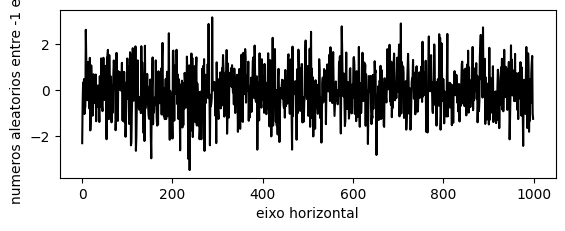

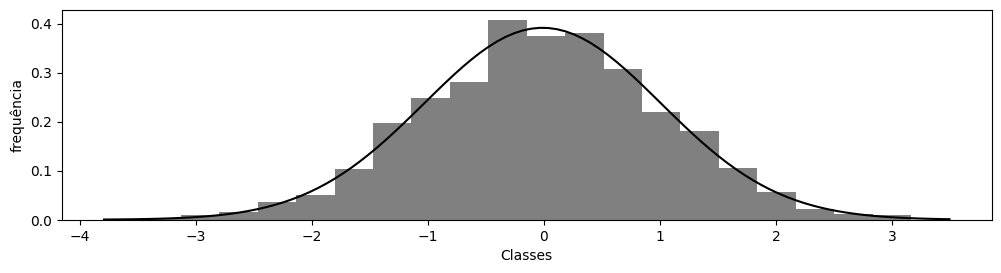

In [8]:
aleat = []
for i in range(1000):
    x = random.gauss(0,1)
    aleat.append(x)

plt.subplot(211)
plt.plot(aleat,color='black')
plt.xlabel('eixo horizontal')
plt.ylabel('numeros aleatorios entre -1 e 1')

plt.figure(figsize=(12,6))

plt.subplot(212)
plt.hist(aleat, bins=20, color='gray',density=True)
plt.xlabel('Classes')
plt.ylabel('frequência')

xmin, xmax = plt.xlim()
media = st.mean(aleat)
desvio = st.pstdev(aleat)
eixo_x = np.linspace(xmin,xmax,100)
eixo_y = norm.pdf(eixo_x, media,desvio)
plt.plot(eixo_x, eixo_y, color='black')

In [23]:
df = pd.read_csv('BOVA11_Daily.csv', sep='\t', usecols=['<DATE>','<OPEN>','<HIGH>','<LOW>','<CLOSE>'])
df = df.rename(columns={'<DATE>': 'DATE',
'<OPEN>':'OPEN',
'<HIGH>':'HIGH',
'<LOW>':'LOW',
'<CLOSE>':'CLOSE'})
df = df.set_index('DATE')
df.head()

,OPEN,HIGH,LOW,CLOSE
DATE,,,,
2020.02.28,98.94,100.60,96.26,100.60
2020.03.02,100.85,103.38,99.90,102.99
2020.03.03,102.96,105.27,100.50,101.75
2020.03.04,103.99,103.99,101.10,103.10
2020.03.05,102.00,102.10,96.77,98.79


In [ ]:
lin = df.shape[0]
col = df.shape[1]
dados = []

dias = np.arange(0, lin)

df['RETORNO DIARIO'] = df['CLOSE'].pct_change()
df.head()

,OPEN,HIGH,LOW,CLOSE,RETORNO DIARIO
DATE,,,,,
2020.02.28,98.94,100.60,96.26,100.60,NaN
2020.03.02,100.85,103.38,99.90,102.99,0.023757
2020.03.03,102.96,105.27,100.50,101.75,-0.012040
2020.03.04,103.99,103.99,101.10,103.10,0.013268
2020.03.05,102.00,102.10,96.77,98.79,-0.041804
...,...,...,...,...,...
2026.02.23,186.07,187.39,184.63,185.17,-0.008142
2026.02.24,186.01,188.19,186.00,187.78,0.014095
2026.02.25,188.89,188.96,186.66,187.46,-0.001704


TypeError: probplot() got an unexpected keyword argument 'color'

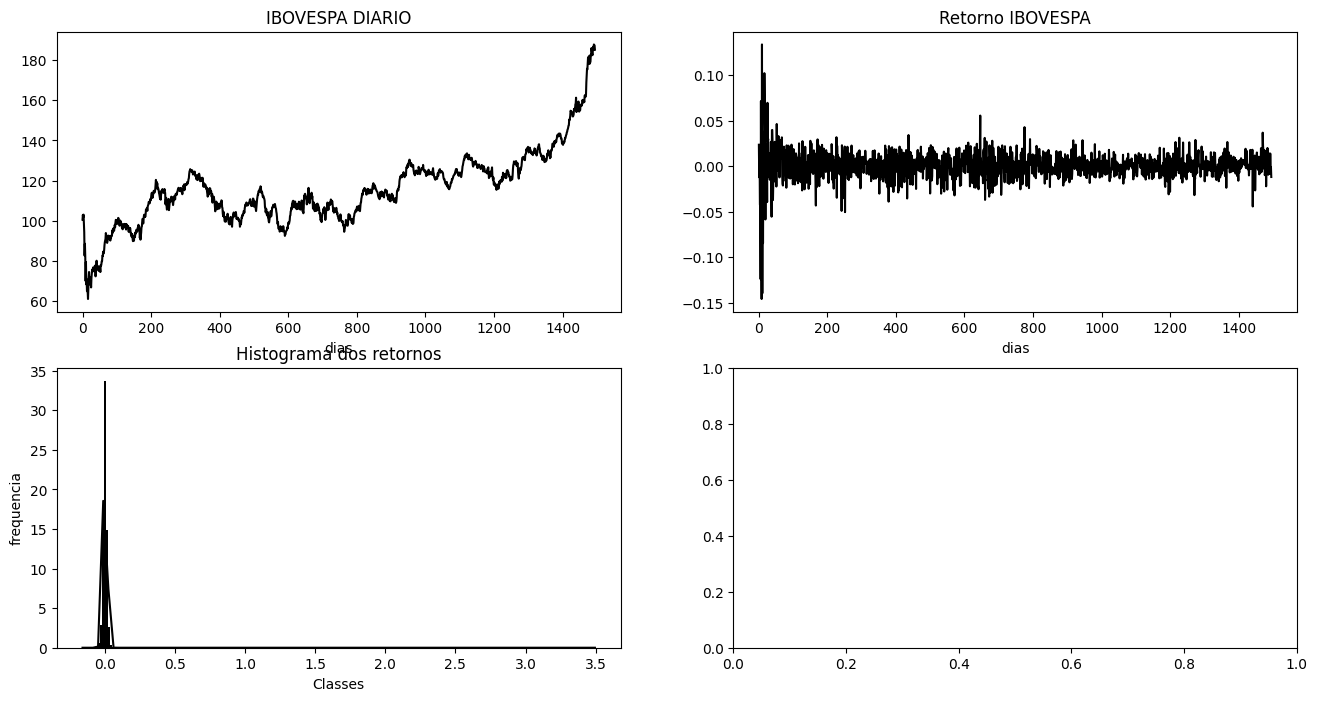

In [ ]:
plt.figure(figsize=(16,8))

plt.subplot(221)
plt.plot(dias, df['CLOSE'], color='black')
plt.xlabel('dias')
plt.title('IBOVESPA DIARIO')

plt.subplot(222)
plt.plot(dias, df['RETORNO DIARIO'], color='black')
plt.xlabel('dias')
plt.title('Retorno IBOVESPA')

plt.subplot(223)
plt.hist(df['RETORNO DIARIO'], bins=20, color='black',density=True)
plt.xlabel('Classes')
plt.ylabel('frequencia')
plt.title('Histograma dos retornos')
xmin, xmam = plt.xlim()
media = (df['RETORNO DIARIO']).mean()
desvio = (df['RETORNO DIARIO']).std()
eixo_x = np.linspace(xmin, xmax, 100)
eixo_y = norm.pdf(eixo_x, media, desvio)
plt.plot(eixo_x, eixo_y, color='black')

plt.subplot(224)
sci.probplot(df['RETORNO DIARIO'], dist='norm', plot=plt)
plt.title('QQ-plot Ibovespa')